# TODO:
- Make basis for profiles normilized by rs and fit only alpha and rho_s
- make residual plots as a function of terms in the expansion
- make a basis with less parameters based on Einasto?
- make residuals in acceleration and potential
-

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

import numpy as np
import h5py
import sys

sys.path.append('../src/')
# from density_profiles import read_density_profile  # Removed: function not found here
from data_ios import read_density_profile  # Correct import

import plot_config
import data_ios 
#from config import DATA_PATH, TEMP_DATA_PATH, FIGURES_PATH
from colossus.halo import profile_einasto
from colossus.cosmology import cosmology
from profiles import Profiles
from exp_pipeline import compute_basis
import pyEXP

In [2]:
density_filename = '../data/tng35-3-dark/halo_21537_density_profiles.hdf5'
cosmo = cosmology.setCosmology('planck15')

/tmp/ipykernel_259259/426703117.py:8: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(r), np.log10(rho), color=cmap(norm(snap)), ls='-')
/tmp/ipykernel_259259/426703117.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, '$\\rho$')

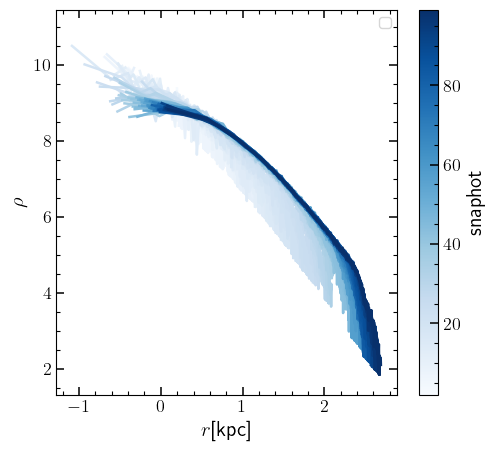

In [22]:
fig, ax = plt.subplots(figsize=(5.5,5))
snaps = range(2, 100)
norm = mpl.colors.Normalize(vmin=min(snaps), vmax=max(snaps))
cmap = plt.cm.Blues

for snap in snaps:
    r, rho = read_density_profile(density_filename, snap=snap)
    ax.plot(np.log10(r), np.log10(rho), color=cmap(norm(snap)), ls='-')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='snaphot')

ax.legend()
ax.set_xlabel('$r$[kpc]')
ax.set_ylabel(r'$\rho$')
#plt.savefig('../temp_figures/halo_21537_density_profile.png', bbox_inches='tight')

In [4]:
halo_params = data_ios.read_halo_params("../data/tng35-3-dark/halo_21537_params.hdf5")
cvir = halo_params['cvir']
Mvir = halo_params['Mvir']
snap = halo_params['snap']

In [5]:
Mvir

array([6.19772109e+08, 1.16466141e+09, 2.96100101e+09, 5.27224022e+09,
       7.43129329e+09, 1.33339510e+10, 1.84219882e+10, 2.59300674e+10,
       2.98079165e+10, 3.44811658e+10, 4.08239129e+10, 4.95551795e+10,
       5.18587847e+10, 5.84554452e+10, 6.46989860e+10, 7.34942920e+10,
       8.75572187e+10, 9.90820858e+10, 1.21599548e+11, 1.39667208e+11,
       1.94647135e+11, 2.49424735e+11, 2.87725994e+11, 3.32790866e+11,
       3.41205931e+11, 3.71014450e+11, 4.07859155e+11, 4.35450565e+11,
       4.74603903e+11, 4.88819024e+11, 4.95806721e+11, 5.03199288e+11,
       5.05461671e+11, 5.02310521e+11, 5.13138297e+11, 5.56347637e+11,
       6.20548169e+11, 6.98338919e+11, 7.22976510e+11, 7.76816545e+11,
       8.05534454e+11, 8.17097297e+11, 8.13405080e+11, 8.21885165e+11,
       8.27403692e+11, 8.37792459e+11, 8.50536607e+11, 8.64175628e+11,
       8.75543059e+11, 9.06201141e+11, 9.22650852e+11, 9.36462625e+11,
       9.49788778e+11, 9.85753697e+11, 9.91362913e+11, 9.94777411e+11,
      

In [6]:
halo_params.keys()

dict_keys(['M200c', 'Mvir', 'R200c', 'Rvir', 'c200c', 'cvir', 'snap'])

In [7]:
halo_params['R200c']/halo_params['c200c']

array([ 0.12150354,  0.17009668,  0.27194043,  0.36606908,  0.43768821,
        0.59112154,  0.71103487,  0.85814351,  0.95337992,  1.04267651,
        1.1954056 ,  1.39016786,  1.45210809,  1.60061811,  1.75066652,
        1.91844302,  2.18653033,  2.41482749,  2.76251597,  3.03077613,
        3.71413043,  4.33196871,  4.82683545,  5.50414433,  5.69469128,
        6.16504073,  6.68803209,  7.14639716,  7.68856744,  8.05401187,
        8.36487428,  8.67264828,  8.94124436,  9.16290601,  9.49265952,
       10.08380162, 10.84083213, 11.68299252, 11.99774824, 12.78710148,
       13.25878607, 13.60215266, 13.82774159, 14.14972986, 14.4341741 ,
       14.76371992, 15.11006745, 15.45859431, 15.72708957, 16.24927377,
       16.63056284, 16.96852422, 17.2986416 , 17.80822143, 18.0920581 ,
       18.32900862, 18.53120301, 18.67581433, 18.85651494, 19.02435563,
       19.1639317 , 19.18963108, 19.32095369, 19.4742097 , 19.74655581,
       20.10447999, 20.32355073, 20.59439843, 20.92254147, 21.25

In [32]:
rs = {}
i=0
for snap in snaps:
    rs[snap] = halo_params['Rvir'][i]/halo_params['cvir'][i]    
    i+=1

/tmp/ipykernel_259259/3070850440.py:8: RuntimeWarning: divide by zero encountered in log10
  ax[0].plot(np.log10(r), np.log10(rho), color=cmap(norm(snap)), ls='-')
/tmp/ipykernel_259259/3070850440.py:9: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(np.log10(r/rs[snap]), np.log10(rho), color=cmap(norm(snap)), ls='-')
/tmp/ipykernel_259259/3070850440.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


Text(0, 0.5, '$\\rho$')

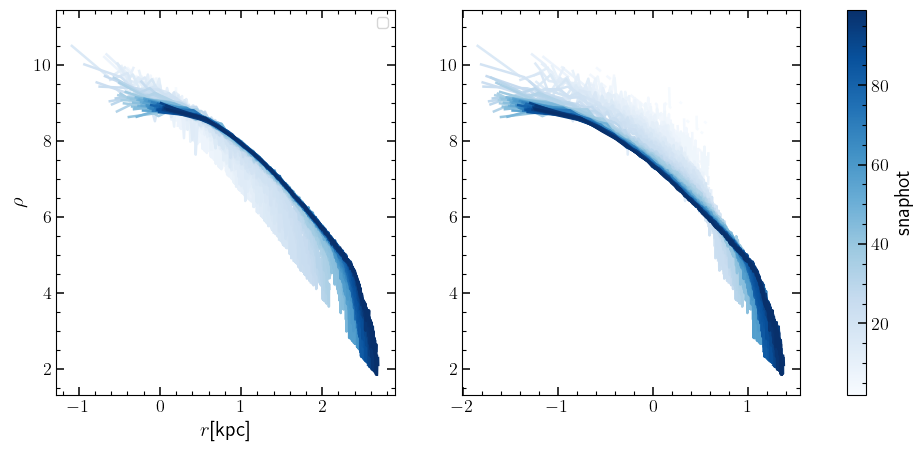

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
snaps = range(2, 100)
norm = mpl.colors.Normalize(vmin=min(snaps), vmax=max(snaps))
cmap = plt.cm.Blues

for snap in snaps:
    r, rho = read_density_profile(density_filename, snap=snap)
    ax[0].plot(np.log10(r), np.log10(rho), color=cmap(norm(snap)), ls='-')
    ax[1].plot(np.log10(r/rs[snap]), np.log10(rho), color=cmap(norm(snap)), ls='-')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='snaphot')

ax[0].legend()
ax[0].set_xlabel('$r$[kpc]')
ax[0].set_ylabel(r'$\rho$')
#plt.savefig('../temp_figures/halo_21537_density_profile.png', bbox_inches='tight')

In [10]:
sims_snaps, redshifts, times, _ = np.loadtxt("../data/tng35-3-dark/tng35-3-dark_halo_time_evol.txt", unpack=True)

In [11]:
#len(rvir)
#rho200c = halo_paramsa['M200c']/(4/3. * np.pi * halo_params['R200c']**3)
#M200c = hablo_paarams['M200ac']

In [13]:
def einasto_profile(r, rho_s, r_s, alpha):
    return rho_s * np.exp(-2.0/alpha * (((r/r_s)**alpha)-1))

In [14]:
#p_einasto = profile_einasto.EinastoProfile(M = Mvir[-1], c = cvir[-1], z = redshifts[-1], mdef = 'vir')

In [15]:
rho_einasto = einasto_profile(r, rho_s=2e7, r_s=30, alpha=0.5)

/tmp/ipykernel_259259/3643783714.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(r), np.log10(rho), c='C0', ls='-')


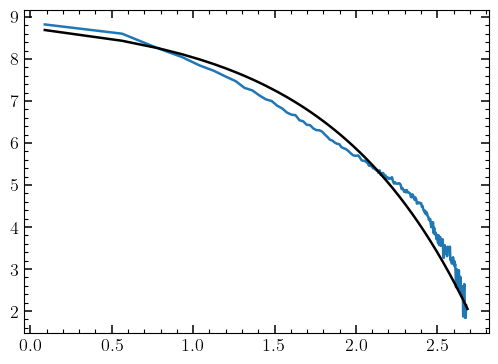

In [16]:
plt.plot(np.log10(r), np.log10(rho), c='C0', ls='-')
plt.plot(np.log10(r), np.log10(rho_einasto), ls='-', c='k')


In [17]:
def fit_einasto_profile(x, y, verbose=False):
    """
    Fit an Einasto density profile to data using robust log-space fitting.

    Fitting in log-space equalizes weighting across the many orders of magnitude
    spanned by a density profile. Robustness is improved through:
    - Multiple initial guesses to avoid local minima
    - Strict convergence criteria

    Parameters
    ----------
    x : array-like
        Dimensionless radius (e.g., r/r200c).
    y : array-like
        Measured (dimensionless) density profile at x.
    verbose : bool, optional
        Print fitting details.

    Returns
    -------
    popt : ndarray
        Best-fit parameters: [rho_s, r_s, alpha].
    pcov : 2d ndarray
        Covariance matrix of the fit.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Mask out non-positive values (would produce -inf / NaN in log)
    mask = (y > 0) & np.isfinite(y)
    x, y = x[mask], y[mask]

    log_y = np.log10(y)
    
    if verbose:
        print(f"Data range: {len(x)} points")

    def log_model(x, rho_s, r_s, alpha):
        return np.log10(rho_s) + np.log10(np.exp(-2.0/alpha * (((x/r_s)**alpha) - 1)))

    # Try multiple initial guesses to avoid local minima
    rho_s_candidates = [np.max(y), np.percentile(y, 90), np.percentile(y, 95)]
    r_s_candidates = [0.05, 10, 20, 30, 40]
    alpha_candidates = [0.3, 0.4, 0.5, 0.8]
    
    best_fit = None
    best_chi2 = np.inf
    
    for rho_s0 in rho_s_candidates:
        for r_s0 in r_s_candidates:
            for alpha0 in alpha_candidates:
                p0 = [rho_s0, r_s0, alpha0]
                
                # Adaptive bounds
                bounds = (
                    [rho_s0 * 1, r_s0 * 0.05, 0.1],
                    [rho_s0 * 1e3,  r_s0 * 20.0, 2.0],
                )
                try:
                    # Use strict convergence criteria
                    popt, pcov = curve_fit(log_model, x, log_y, p0=p0, bounds=bounds,
                                          maxfev=80000, ftol=1e-10, xtol=1e-10)
                    residuals = log_y - log_model(x, *popt)
                    chi2 = np.sum(residuals**2)
                    
                    if chi2 < best_chi2:
                        best_chi2 = chi2
                        best_fit = (popt, pcov)
                        if verbose:
                            print(f"  Try p0={p0}: chi2={chi2:.3g}")
                except Exception as e:
                    if verbose:
                        print(f"  Try p0={p0}: failed")
                    continue
    
    if best_fit is None:
        raise RuntimeError("Fit failed for all initial guesses")
    
    if verbose:
        popt, _ = best_fit
        print(f"Best fit: rho_s={popt[0]:.3g}, r_s={popt[1]:.3f}, alpha={popt[2]:.3f}")
    
    return best_fit

In [18]:
fit_halo, fit_cov = fit_einasto_profile(r, rho)
rho_s_fit, r_s_fit, alpha_fit = fit_halo
profile_fit = einasto_profile(r, rho_s=rho_s_fit, r_s=r_s_fit, alpha=alpha_fit)
print(f"rho_s={rho_s_fit:.3g}, r_s={r_s_fit:.3f}, alpha={alpha_fit:.3f}")

rho_s=5.92e+06, r_s=45.084, alpha=0.561


/tmp/ipykernel_259259/247548533.py:39: RuntimeWarning: divide by zero encountered in log10
  return np.log10(rho_s) + np.log10(np.exp(-2.0/alpha * (((x/r_s)**alpha) - 1)))


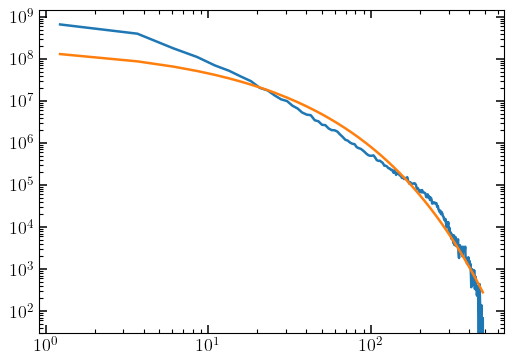

In [19]:
plt.loglog(r, rho)
plt.loglog(r, profile_fit)
#plt.ylim(1e-4, 1e5)
#plt.xlim(2e-3, 10)

In [20]:
# Fit Einasto profiles for all snapshots and store results
all_fit_params = {}  # Store: snap -> (rho_s, r_s, alpha)
all_profile_fits = {}  # Store: snap -> profile_fit array
all_rho = {}  # Store: snap -> r array
all_r = {}
snaps = range(2, 100)

for snap in snaps:
    r, rho = read_density_profile(density_filename, snap=snap)
    all_r[snap] = r
    all_rho[snap] = rho
    
    
    # Fit the profile for this snapshot
    fit_halo, fit_cov = fit_einasto_profile(r, rho, verbose=False)
    rho_s_fit, r_s_fit, alpha_fit = fit_halo
    
    # Store parameters
    all_fit_params[snap] = {
        'rho_s': rho_s_fit,
        'r_s': r_s_fit,
        'alpha': alpha_fit,
    }
    
    # Compute and store profile fit
    profile_fit = einasto_profile(r, rho_s=rho_s_fit, r_s=r_s_fit, alpha=alpha_fit)
    all_profile_fits[snap] = profile_fit



/tmp/ipykernel_259259/247548533.py:39: RuntimeWarning: divide by zero encountered in log10
  return np.log10(rho_s) + np.log10(np.exp(-2.0/alpha * (((x/r_s)**alpha) - 1)))


/tmp/ipykernel_213529/688120632.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(all_r[i], np.abs(all_rho[i]-all_profile_fits[i])/all_rho[i])


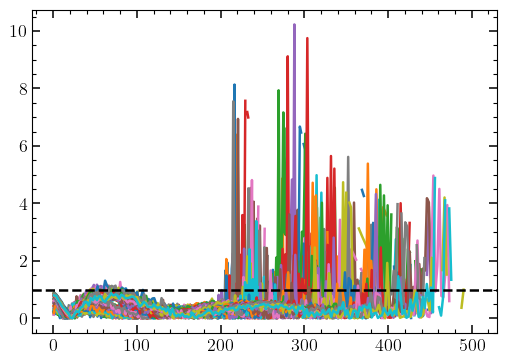

In [17]:
for i in range(50, 100):
    plt.plot(all_r[i], np.abs(all_rho[i]-all_profile_fits[i])/all_rho[i])
plt.axhline(1, c='k', ls='--')

In [18]:
# Save all fit parameters and profiles to HDF5 files
output_params_file = '../data/tng35-3-dark/halo_21537_einasto_fit_params.h5'
output_profiles_file = '../data/tng35-3-dark/halo_21537_einasto_profiles.h5'

# Save parameters
with h5py.File(output_params_file, 'w') as f:
    for snap in all_fit_params.keys():
        grp = f.create_group(f'snap_{snap:03d}')
        grp.attrs['snap'] = snap
        grp.create_dataset('rho_s', data=all_fit_params[snap]['rho_s'])
        grp.create_dataset('r_s', data=all_fit_params[snap]['r_s'])
        grp.create_dataset('alpha', data=all_fit_params[snap]['alpha'])

print(f"Saved fit parameters to {output_params_file}")

# Save profiles
with h5py.File(output_profiles_file, 'w') as f:
    for snap in all_profile_fits.keys():
        grp = f.create_group(f'snap_{snap:03d}')
        grp.attrs['snap'] = snap
        grp.create_dataset('r', data=all_r[snap])
        grp.create_dataset('rho_einasto', data=all_profile_fits[snap])

print(f"Saved fit profiles to {output_profiles_file}")

Saved fit parameters to ../data/tng35-3-dark/halo_21537_einasto_fit_params.h5
Saved fit profiles to ../data/tng35-3-dark/halo_21537_einasto_profiles.h5


In [19]:
def load_einasto_fits(params_file, profiles_file):
    """
    Load Einasto profile fit parameters and profiles from HDF5 files.
    
    Parameters
    ----------
    params_file : str
        Path to the fit parameters HDF5 file.
    profiles_file : str
        Path to the profiles HDF5 file.
    
    Returns
    -------
    fit_params : dict
        Dictionary with snapshot numbers as keys and parameter dicts as values.
        Each parameter dict contains 'rho_s', 'r_s', 'alpha'.
    profiles : dict
        Dictionary with snapshot numbers as keys.
        Each entry contains 'r' and 'rho_einasto' arrays.
    """
    fit_params = {}
    profiles = {}
    
    # Load parameters
    with h5py.File(params_file, 'r') as f:
        for group_name in sorted(f.keys()):
            grp = f[group_name]
            snap = grp.attrs['snap']
            fit_params[snap] = {
                'rho_s': grp['rho_s'][()],
                'r_s': grp['r_s'][()],
                'alpha': grp['alpha'][()],
            }
    
    # Load profiles
    with h5py.File(profiles_file, 'r') as f:
        for group_name in sorted(f.keys()):
            grp = f[group_name]
            snap = grp.attrs['snap']
            profiles[snap] = {
                'r': grp['r'][:],
                'rho_einasto': grp['rho_einasto'][:],
            }
    
    return fit_params, profiles

# Example usage:
fit_params, profiles = load_einasto_fits(
     '../data/tng35-3-dark/halo_21537_einasto_fit_params.h5',
     '../data/tng35-3-dark/halo_21537_einasto_profiles.h5'
 )

In [20]:
# Recompute einasto profiles on upsampled grid (2000 bins)
upsampled_profiles = {}

for snap in sorted(fit_params.keys()):
    # Get original radial range
    r_min = profiles[snap]['r'][0]
    r_max = profiles[snap]['r'][-1]
    
    # Create upsampled radial array with 2000 bins
    r_upsample = np.linspace(r_min, r_max, 2000)
    
    # Get fit parameters for this snapshot
    rho_s = fit_params[snap]['rho_s']
    r_s = fit_params[snap]['r_s']
    alpha = fit_params[snap]['alpha']
    
    # Compute einasto profile at upsampled distances
    rho_upsample = einasto_profile(r_upsample, rho_s=rho_s, r_s=r_s, alpha=alpha)
    
    upsampled_profiles[snap] = {
        'r': r_upsample,
        'rho': rho_upsample,
    }

print(f"Computed upsampled profiles for {len(upsampled_profiles)} snapshots")
print(f"Example: snap {list(upsampled_profiles.keys())[0]} has {len(upsampled_profiles[list(upsampled_profiles.keys())[0]]['r'])} radial bins")

Computed upsampled profiles for 98 snapshots
Example: snap 2 has 2000 radial bins


In [21]:
def build_basis(r_basis, rho_basis, nmax, lmax, snap, Mtot=1.0):
    basis_params = {
        'rmin': r_basis[0],
        'rmax': r_basis[-1],
        'rmapping': 1.0,  # If rmapping is a float, otherwise use the correct type
        'Mtotal': Mtot,
        'nbins': len(r_basis),
        'lmax': lmax,
        'nmax': nmax,
        'cachename': 'halo_21537_basis_cache_{:02d}_{:02d}_{:02d}.txt'.format(nmax, lmax, snap),
        'modelname': 'halo_21537_model_{:02d}_{:02d}_{:02d}.txt'.format(nmax, lmax, snap),
        'basis_id': 'sphereSL',
    }

    basis_path = './'
    basis_filename = 'halo_21537_basis_config_{:02d}.yaml'.format(snap)

    basis = compute_basis(basis_params, r_basis, rho_basis, basis_path, basis_filename)
    return basis

In [ ]:
print(upsampled_profiles[98]['r'][-1],)
print(upsampled_profiles[98]['r'][-800],  np.sum(upsampled_profiles[98]['rho'][:-800])*v2)

505.48143771745066 3.074347856900503e+18
303.95093796002215 6.639051577717533e+17


In [38]:

v1 = 4*np.pi*(505**3) / 3.
v2 = 4*np.pi*(303**3) / 3.

M1 =  np.sum(upsampled_profiles[98]['rho'][:-1])*v1
M2 =  np.sum(upsampled_profiles[98]['rho'][:-800])*v2

print(M1, M2, M2/M1)

3.074347856900503e+18 6.639051577717533e+17 0.21594991480277365


In [ ]:
nmax= 15
lmax = 6
all_basis = {}
#basis = build_basis(r/rvir[-1], profile_fit, nmax=nmax, lmax=lmax)
for snap in range(49, 100, 10):
    try:
        #plt.plot(all_r[i], np.abs(all_rho[i]-all_profile_fits[i])/all_rho[i])
        all_basis[snap] = build_basis(upsampled_profiles[snap]['r'], upsampled_profiles[snap]['rho'], nmax=nmax, lmax=lmax, snap=snap)
        print("Done computing basis {:02d}".format(snap))
    except Exception as e:
        print(f"Skipping snap={snap}: {type(e).__name__}: {e}")

! Scaling: R = 213.15854535704108  M = 1.0
Scaling factors: rfac = 1.0, dfac = 8.454551689057686e-14, mfac = 8.454551689057686e-14, pfac = 8.454551689057686e-14
---- SLGridSph::ReadH5Cache: successfully read basis cache <halo_21537_basis_cache_15_06_49.txt>
Done computing basis 49
---- Spherical::orthoTest: worst=0.00968586
! Scaling: R = 266.6361389711033  M = 1.0
Scaling factors: rfac = 1.0, dfac = 7.476639653506513e-14, mfac = 7.476639653506513e-14, pfac = 7.476639653506513e-14
---- SLGridSph::ReadH5Cache: Done computing basis 59
successfully read basis cache <halo_21537_basis_cache_15_06_59.txt>
---- Spherical::orthoTest: worst=0.0109727
! Scaling: R = 316.13271716331616  M = 1.0
Scaling factors: rfac = 1.0, dfac = 7.385539624982924e-14, mfac = 7.385539624982923e-14, pfac = 7.385539624982924e-14
---- SLGridSph::ReadH5Cache: successfully read basis cache <halo_21537_basis_cache_15_06_69.txt>
---- Spherical::orthoTest: worst=0.00873369
Done computing basis 69
! Scaling: R = 379.30940

---- SLGridSph::ReadH5Cache: error reading <halo_21537_basis_cache_15_06_99.txt>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file halo_21537_basis_cache_15_06_99.txt (File accessibility) Unable to open file>


In [24]:
def read_tng_halo_particles(filename):
    """
    Read halo particle coordinates and group properties from a TNG HDF5 file.

    The function automatically detects the halo ID contained in the key
    'galaxy_XXXXXX_ptldm_Coordinates'.

    Parameters
    ----------
    filename : str
        Path to HDF5 file.

    Returns
    -------
    coords : ndarray, shape (N,3)
        Dark matter particle positions [kpc].
    marr : mass array 
    """
    mass_tng = 2.33443590182933*1e7

    with h5py.File(filename, 'r') as f:

        # Find coordinate key dynamically
        coord_key = None
        for key in f.keys():
            if key.startswith("galaxy_") and key.endswith("_ptldm_Coordinates"):
                coord_key = key
                break

        if coord_key is None:
            raise KeyError("No halo coordinate key found in file.")

        halo_id = coord_key.split('_')[1]

        coords = f[coord_key][:]
     
    marr = np.ones(len(coords)) * mass_tng
    return coords, marr 

In [25]:
import os
from exp_coefficients import compute_exp_coefs

sim = "tng35-3-dark"
halo_subfind_id = 21537
mass_tng = 2.33443590182933*1e7
units = [('mass', 'Msun', mass_tng),
             ('length', 'kpc', 1.0),
             ('velocity', 'km/s', 1.0),
             ('G', 'mixed', 43007.1)]

snap_basename = "galaxies_halo_{subfind_id}_tng50-3-dark_{snap:03d}.hdf5"


i=0
for snap in range(49, 100, 10):
    input_snap = os.path.join("../data/", sim, 
                                snap_basename.format(subfind_id=halo_subfind_id, snap=snap))
    coords, masses = read_tng_halo_particles(input_snap)
    halo_data = {'pos' : coords, 'mass': masses}
    compute_exp_coefs(halo_data=halo_data, 
                  snap_time=snap, 
                  basis=all_basis[snap], 
                  component='halo', 
                  coefs_file='halo_21537_coefficients_{:02d}_{:02d}.h5'.format(nmax, lmax), 
                  unit_system=units)
    i+=1

> Done computing coefficients*Coefs::WriteH5Units: wrote units to HDF5 file:

------------------------------------------------
            Name            Unit           Value
      ----------      ----------      ----------
               G           mixed         43007.1
            mass            Msun     2.33444e+07
          length             kpc               1
        velocity            km/s               1
------------------------------------------------

> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*


In [26]:
coefs = pyEXP.coefs.Coefs.factory("halo_21537_coefficients_{:02d}_{:02d}.h5".format(nmax, lmax))

In [27]:
from grid import Grid3D

def bfe_density_profiles(
    basis,
    coefs,
    r_bins,
    theta_bins=20,
    phi_bins=40,
    time=0.0,
    field="dens",
    statistic="median",
):
    """
    Compute a spherically averaged density profile from a BFE by
    sampling the density field on a spherical grid at specified
    radial bin centers.

    Parameters
    ----------
    basis : pyEXP basis object
    coefs : pyEXP coefficients
    r_bins : array-like
        Radial bin centers at which the density is evaluated.
    theta_bins : int, optional
        Number of azimuthal samples.
    phi_bins : int, optional
        Number of polar samples.
    time : float, optional
        Snapshot time.
    field : str, optional
        Field name to extract (default: 'dens').
    statistic : {'mean', 'median'}, optional
        Angular statistic to compute at each radius.

    Returns
    -------
    ndarray
        Spherically averaged density evaluated at each radius.
    """

    r_bins = np.asarray(r_bins)

    # Build spherical grid at bin centers
    grid = Grid3D(
        system="spherical",
        ranges=[(r_bins.min(), r_bins.max()), None, None],
        num_points=[len(r_bins), theta_bins, phi_bins],
        r_bins=r_bins,
    )

    xyz = grid.to("cartesian")

    # Evaluate field
    fields = pyEXP.field.FieldGenerator([time], xyz)
    field_data = fields.points(basis, coefs)[time]

    if field not in field_data:
        raise ValueError(
            f"Field '{field}' not available. "
            f"Available fields: {list(field_data.keys())}"
        )

    dens = field_data[field]

    # Reshape: (nr, ntheta * nphi)
    nr = len(r_bins)
    dens = dens.reshape(nr, -1)

    if statistic == "mean":
        profile = np.mean(dens, axis=1)
    elif statistic == "median":
        profile = np.median(dens, axis=1)
    else:
        raise ValueError("statistic must be 'mean' or 'median'")

    return profile

In [28]:
bfe_profiles = {}
snaps = np.arange(49, 100, 10)
for coef_ts, snap in zip(coefs.Times(), snaps):
    bfe_profiles[snap] = bfe_density_profiles(
                            basis=all_basis[snap], 
                            coefs=coefs, 
                            r_bins=profiles[snap]['r'], 
                            time=coef_ts, 
                            statistic='median', 
                            theta_bins=25, 
                            phi_bins=50)

In [30]:
masses[0] / mass_tng 

np.float64(1.0)

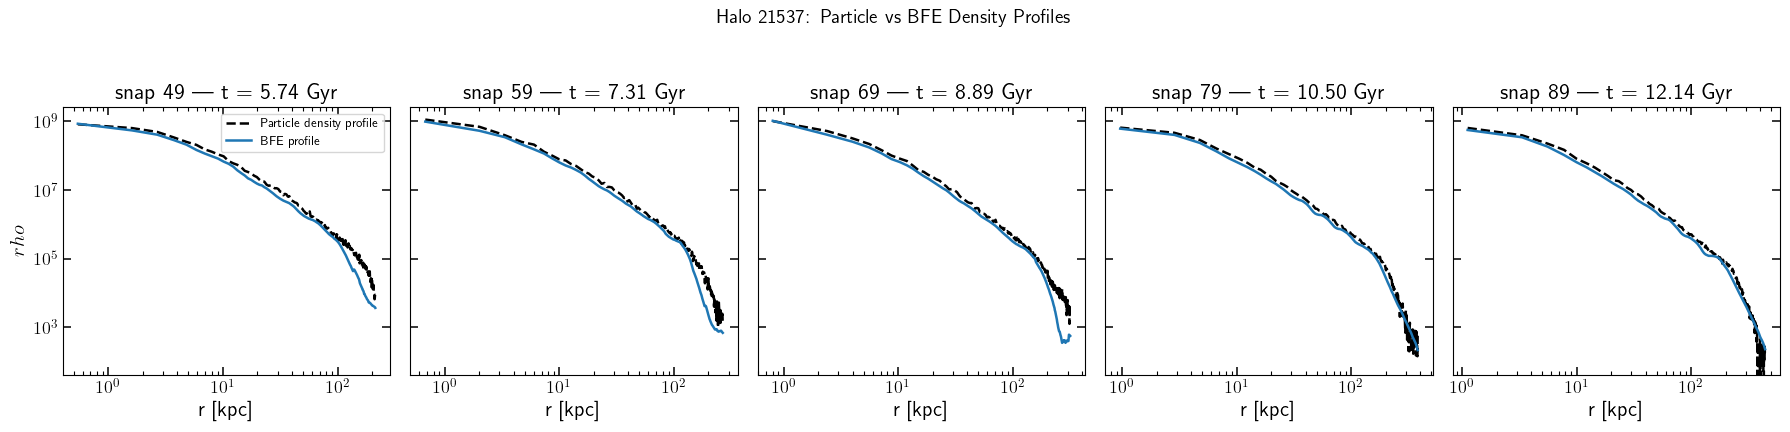

In [41]:
# Build a snap -> time [Gyr] lookup if simulation timeline arrays are available.
# Falls back `to coefficient times for the plotted snapshots.
if 'sims_snaps' in globals() and 'times' in globals():
    snap_to_time = {int(s): float(t) for s, t in zip(sims_snaps, times)}
else:
    snap_to_time = {int(s): float(t) for s, t in zip(snaps, coefs.Times())}

# Use exactly 5 panels as requested.
snaps = np.arange(49, 100, 10)
snaps_to_plot = snaps[:5]

# Halo label for titles.
halo_name = f"Halo {halo_subfind_id}" if 'halo_subfind_id' in globals() else "Halo 21537"

fig, ax = plt.subplots(1, 5, figsize=(18, 4.5), sharey=True)

for i, snap in enumerate(snaps_to_plot):
    t_gyr = snap_to_time.get(int(snap), np.nan)

    ax[i].loglog(
        all_r[snap],
        all_rho[snap],
        color='k',
        ls='--',
        label='Particle density profile'
    )
    ax[i].loglog(
        profiles[snap]['r'],
        bfe_profiles[snap]*16.6,
        c='C0',
        label='BFE profile'
    )

    ax[i].set_title(f"snap {snap} | t = {t_gyr:.2f} Gyr")
    ax[i].set_xlabel('r [kpc]')

ax[0].set_ylabel(r'$\\rho$')
ax[0].legend(fontsize=9)
fig.suptitle(f"{halo_name}: Particle vs BFE Density Profiles", fontsize=14)
fig.tight_layout(rect=[0, 0.03, 1, 0.92])

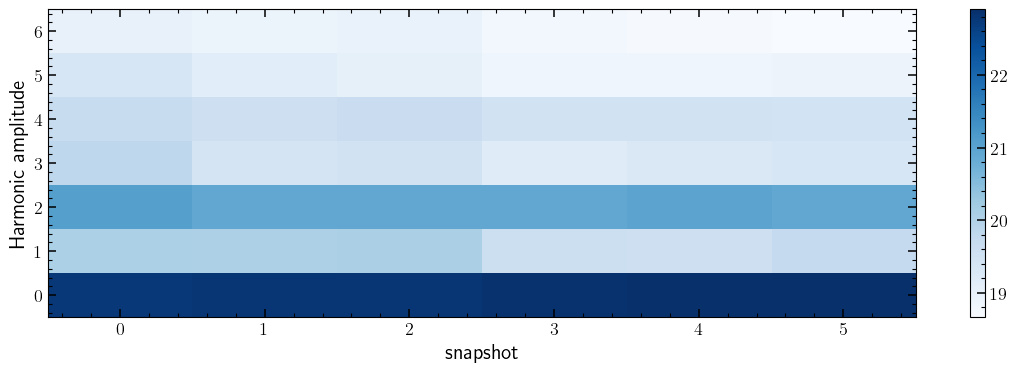

In [42]:
plt.figure(figsize=(14, 4))
plt.imshow(np.log10(coefs.Power().T), cmap='Blues', origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel('snapshot')
plt.ylabel('Harmonic amplitude')
plt.savefig('../temp_figures/coeffs_evolution.png', bbox_inches='tight')

In [94]:
from compute_fields import compute_bfe_fields

In [95]:
# Create grid
grid_range=[-2, 2]
grid_bins = 50
dbins = np.linspace(grid_range[0], grid_range[1], grid_bins)
grid_arrays = np.meshgrid(dbins, dbins, dbins, indexing="ij")
grid = np.stack(grid_arrays)

In [96]:
t = coefs.Times()
print(t)

[2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0]


In [99]:

from field_io import write_fields
for i in range(0, 96):
    dens_bfe_list, FP, points = compute_bfe_fields(grid, basis, coefs, eval_times=[t[i]])
    #im = plt.imshow(np.log10(np.abs(np.nanmean(points[t[i]]['dens'].reshape(grid_bins, grid_bins, grid_bins), axis=1))), extent=[-2, 2, -2, 2], cmap='twilight', vmin=4, vmax=14)
    #plt.colorbar(im)

    #plt.xlabel(r'$x/r_{200c}$')
    #plt.ylabel(r'$y/r_{200c}$')
    #plt.savefig('../temp_figures/halo_21537_density_field_{:03d}.png'.format(int(t[i])), bbox_inches='tight')
    #plt.close()
    #print('Done snap')
    write_fields(points, "../data/bfe_density/halo_21537_BFE_density_{nmax:02d}_{lmax:02d}_{snap:03d}.h5".format(nmax=nmax, lmax=lmax, snap=i+2), grid=None, field_shape=[50, 50, 50])


Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_002.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_003.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_004.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_005.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_006.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_007.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_008.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_009.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_010.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_BFE_density_16_08_011.h5
Computing EXP fields

In [22]:
import os
import sys
import numpy as np
sys.path.append('../src/')
from compute_fields import compute_kde_density
import data_ios
from field_io import write_kde_densit
dbins = np.linspace(-2, 2, 50)
grid_arrays = np.meshgrid(dbins, dbins, dbins, indexing="ij")
grid = np.stack(grid_arrays) 


snap_basename = "galaxies_halo_{subfind_id}_tng50-3-dark_{snap:03d}.hdf5"
snaps = list(range(2, 99))

sim = "tng35-3-dark"
halo_subfind_id = 21537
mass_tng = 4.8e8


halo_params = data_ios.read_halo_params("../data/tng35-3-dark/halo_21537_params.hdf5")
r200c = halo_params['R200c']

i=0
for snap in snaps:
    input_snap = os.path.join("../data/", sim, snap_basename.format(subfind_id=halo_subfind_id, snap=snap))
    coords, masses = data_ios.read_tng_halo_particles(input_snap)
    halo_data = {'pos' : coords/r200c[i], 'mass': masses}
    kde_density_field = compute_kde_density(halo_data['pos'], halo_data['mass'], grid)
    write_kde_density(kde_density_field, "../data/kde_density/halo_{}_kde_density_field_{:03d}.h5".format(21537, i+2), (50, 50, 50), input_snap, Ndens=64)
    i+=1

---- KDdensity: finished density estimate with 0 undetermined densities, mass=1.104e+10
---- KDdensity: a few densities are 4.08886e+08, 4.54578e+08, 4.8884e+08
---- KDdensity: bad density count is 0 of 23 particles.
KDE density written to ../data/kde_density/halo_21537_kde_density_field_002.h5
---- KDdensity: finished density estimate with 0 undetermined densities, mass=2.64e+10
---- KDdensity: a few densities are 1.90164e+09, 3.79279e+08, 3.36448e+08
---- KDdensity: bad density count is 0 of 55 particles.
KDE density written to ../data/kde_density/halo_21537_kde_density_field_003.h5
---- KDdensity: finished density estimate with 0 undetermined densities, mass=4.416e+10
---- KDdensity: a few densities are 1.55413e+10, 9.04753e+09, 6.43406e+09
---- KDdensity: bad density count is 0 of 92 particles.
KDE density written to ../data/kde_density/halo_21537_kde_density_field_004.h5
---- KDdensity: finished density estimate with 0 undetermined densities, mass=8.256e+10
---- KDdensity: a few d

In [23]:
from field_io import merge_kde_density_files

In [25]:
merge_kde_density_files('../data/kde_density/halo_21537_kde_density_field*.h5' ,'../data/kde_density/halo_21537_kde_density_field.h5')

Merged 97 KDE density files into ../data/kde_density/halo_21537_kde_density_field.h5


In [145]:
basis.getFieldsCoefs(i, 0, 0, coefs)[0].keys()

dict_keys(['azi force', 'dens', 'dens m=0', 'dens m>0', 'mer force', 'potl', 'potl m=0', 'potl m>0', 'rad force'])

In [146]:
r, rho = read_density_profile(density_filename, snap=snaps[-1])
rbins = r/rvir[-1]
bfe_profile = np.zeros_like(rbins)
j=0
for i in rbins:
    bfe_profile[j] = basis.getFieldsCoefs(i, 0, 0, coefs)[0]['dens m=0'][-1]
    j+=1

In [157]:
np.sum(masses)/1e12

np.float64(16.60368)

/tmp/ipykernel_8995/3179651465.py:1: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(rbins), np.log10(bfe_profile/len(masses)), c='C0', ls='--')
/tmp/ipykernel_8995/3179651465.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(r/rvir[-1]), np.log10(rho), c='k', ls='-')


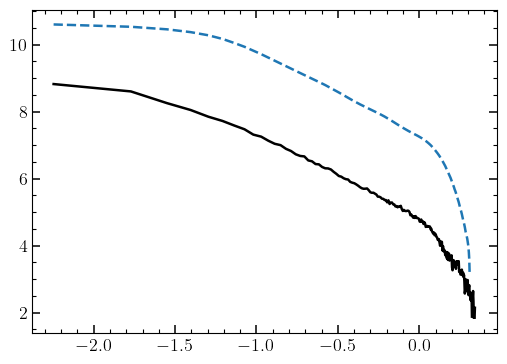

In [156]:
plt.plot(np.log10(rbins), np.log10(bfe_profile/len(masses)), c='C0', ls='--')
r, rho = read_density_profile(density_filename, snap=snaps[-1])
plt.plot(np.log10(r/rvir[-1]), np.log10(rho), c='k', ls='-')

In [116]:

fields_coefs = basis.getFieldsCoefs(0, 0.2, 0, coefs)

In [117]:
fields_coefs[0]['dens']

array([-6.75242380e+10,  8.63875839e+11,  1.37858462e+11,  2.80252152e+11,
       -9.96425627e+10,  2.35809372e+10, -2.01643610e+10,  2.37246717e+11,
        7.83097510e+11,  3.96443913e+12,  3.62445351e+11,  1.29102339e+12,
       -7.51679672e+11,  1.88159944e+12,  1.22180036e+12,  5.66039639e+10,
        1.83558705e+12,  1.39591406e+12,  1.05542621e+13,  8.21511381e+11,
        6.10412360e+12,  7.56934886e+12,  4.26618880e+12,  5.44771467e+12,
       -4.67749301e+11,  9.10422903e+12,  1.06873303e+13,  2.97687433e+12,
        4.25220964e+12,  8.55894756e+12,  1.87401436e+12,  1.42946412e+13,
        1.10624351e+13,  7.67647965e+12,  1.69703491e+13,  2.06984675e+13,
        6.13153440e+12,  7.55288880e+12,  1.98137582e+13,  1.83463293e+13,
        1.94908576e+13,  2.75861535e+13,  3.11435311e+13,  1.16634753e+13,
        7.26978465e+12,  1.99761414e+13,  2.48299982e+13,  1.44347934e+13,
        9.82060580e+12,  3.17908342e+13,  1.58852693e+13,  1.22588744e+13,
        1.86522306e+13,  

In [3]:
fig, ax = plt.subplots(figsize=(5.5,5))
snaps = range(2, 100)
norm = mpl.colors.Normalize(vmin=min(snaps), vmax=max(snaps))
cmap = plt.cm.Blues
j=0
for snap in snaps:
    r, rho = read_density_profile(density_filename, snap=snap)
    ax.plot(np.log10(r/rvir[j]), np.log10(rho/rho200c[j]), color=cmap(norm(snap)), ls='-')
    j+=1


sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='snaphot')

ax.legend()
ax.set_xlabel('$r/r_{200c}$[kpc]')
ax.set_ylabel(r'$\rho/\rho_{200c}$')
#plt.savefig('../temp_figures/halo_21537_normalized_fit_density_profile.png', bbox_inches='tight')

NameError: name 'plt' is not defined

In [35]:
coefs.Times()

[98.0]

In [36]:
bfe_prof = bfe_density_profiles(basis=basis, coefs=coefs, r_bins=r/rvir[-1], time=98.0)

/tmp/ipykernel_503991/3710176859.py:2: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(r/rvir[-1]), np.log10((bfe_prof)), c='C0', label='Best fit')


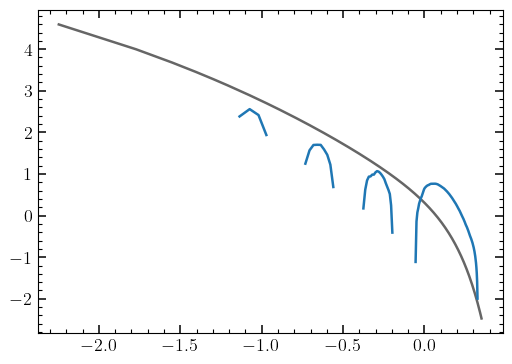

In [38]:
plt.plot(np.log10(r/rvir[-1]), np.log10(profile_fit), c='k', label='Best fit', alpha=0.6)
plt.plot(np.log10(r/rvir[-1]), np.log10((bfe_prof)), c='C0', label='Best fit')
